# Exploratory Data Analysis and Regression Modeling of Body Fat Dataset 


## Project Overview
**Objective:**          
Accurately estimating body fat percentage is important in health, fitness, and clinical contexts, but the most accurate, detailed methods such as DEXA scans or hydrostatic weighing can be expensive and time-consuming. Instead, other simple, low-cost methods such as anthropometric and physiological measurements can be worth considering. The goal of this project is to assess whether these measurements can provide practical predictive value while maintaining acceptable generalization performance.

Using a structured data science workflow, this analysis investigates relationships between body measurements and  body fat percentages, applies regression-based predictive models, and evaluates their performance using cross-validation techniques.

**Python Libraries Used for Analysis:**  
NumPy, Pandas, Matplotlib, scikit-learn


## Dataset Overview
The dataset used titled "560_bodyfat", was sourced from Penn Machine Learning Benchmarks (PMLB) through Github and contains various age, weight, height, and body circumference measurements for 252 men. It includes 14 different features and 1 target variable for body fat percentage determined through hydrostatic weighing. Specifically, the body fat percentage values were derived mathematically using Siri's equation after finding body density values with hydrostatic weighing. 

**Modeling Context**

The primary modeling goal of this analysis is to evaluate how well easily obtainable field measurements can predict body fat percentage. Thus, this project emphasizes general performance and interpretability as opposed to simply reconstructing the equations used for calculating body fat.

**Dataset Link** - [560_bodyfat](https://github.com/EpistasisLab/pmlb/tree/master/datasets/560_bodyfat)


## Imports
Initial imports of python packages, libraries, and the dataset are listed below for subsequent convenience.

In [2]:
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import sklearn.linear_model

In [3]:
bodyfatset = pd.read_csv('https://github.com/EpistasisLab/pmlb/raw/refs/heads/master/datasets/560_bodyfat/560_bodyfat.tsv.gz', sep='\t')
bodyfatset.sample(n=10)

,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,target
164,1.0370,34.0,218.750000,72.00,39.500000,111.400002,106.000000,108.800003,63.799999,42.000000,23.400000,34.000000,31.200001,18.500000,27.299999
51,1.0840,40.0,139.250000,69.00,34.299999,89.199997,77.900002,91.000000,51.400002,34.900002,21.000000,26.700001,26.100000,17.200001,6.600000
235,1.0563,62.0,168.750000,67.50,38.299999,104.699997,95.599998,93.699997,54.400002,37.099998,22.700001,30.299999,26.299999,18.299999,18.600000
243,1.0256,67.0,227.750000,72.75,41.299999,115.800003,113.400002,109.800003,65.599998,46.000000,25.400000,35.299999,29.799999,19.500000,32.599998
21,1.0640,28.0,200.500000,69.75,41.299999,111.400002,98.800003,104.800003,63.400002,40.599998,24.600000,33.000000,32.799999,19.900000,15.200000
156,1.0287,28.0,205.750000,69.00,38.500000,105.599998,105.000000,106.400002,68.599998,40.000000,25.200001,35.200001,30.700001,19.100000,31.200001
108,1.0593,43.0,194.000000,75.50,38.500000,110.099998,88.699997,102.099998,57.500000,40.000000,24.799999,35.099998,30.700001,19.200001,17.299999
203,1.0854,44.0,184.000000,74.00,37.900002,100.800003,89.099998,102.599998,60.599998,39.000000,24.000000,32.900002,29.200001,18.400000,6.000000
144,1.0754,23.0,188.149994,77.50,38.000000,96.599998,85.300003,102.500000,59.099998,37.599998,23.200001,31.799999,29.700001,18.299999,10.300000
6,1.0549,26.0,181.000000,69.75,36.400002,105.099998,90.699997,100.300003,58.400002,38.299999,22.900000,31.900000,27.799999,17.700001,19.200001


bodyfatset = 2D DataFrame, 252 rows, 15 columns including target

### Feature Explanation

A list all of the columns was included with descriptions about each variable

In [4]:
list(bodyfatset.columns)

['Density',
 'Age',
 'Weight',
 'Height',
 'Neck',
 'Chest',
 'Abdomen',
 'Hip',
 'Thigh',
 'Knee',
 'Ankle',
 'Biceps',
 'Forearm',
 'Wrist',
 'target']

**Density** = A physical property describing the relationship between mass/volume, determined here from underwater weighing as stated in the Github metadata measured in g/cm^3

**Age** = A value describing the number of years a person has been alive since birth

**Weight** = A value describing the mass or how "heavy" a person is dependent on gravity, measured in pounds

**Height** = A value describing the vertical length or how "tall" a person is, measured in inches

**Neck** = A value describing the measured circumference in centimeters of the person's neck as stated in the Github metadata

**Chest** = A value describing the measured circumference in centimeters of the person's chest

**Abdomen** = A value describing the measured circumference in centimeters of the person's abdomen/stomach

**Hip** = A value describing the measured circumference in centimeters of the person's hip

**Thigh** = A value describing the measured circumference in centimeters of the person's thigh/upper leg

**Knee** = A value describing the measured circumference in centimeters of the person's knee

**Ankle** = A value describing the measured circumference in centimeters of the person's ankle

**Biceps** = A value describing the measured circumference in centimeters of the person's biceps/upper arm

**Forearm** = A value describing the measured circumference in centimeters of the person's forearm/lower arm

**Wrist** = A value describing the measured circumference in centimeters of the person's wrist

**Target** = A value describing the percentage of body fat for an individual as determined by underwater weighing





# EDA Section

An exploratory data analysis of the data set was performed to assess data quality, understand feature distributions and relationships through graphical representations, and identify any potential outliers. These insights assisted in data preprocessing and subsequent model selection.

3 individual charts were selected to highlight particular variables of interest.


### Data Structure and Summary Statistics

In [5]:
featuresonly = bodyfatset.drop(columns=['target']) #all columns in DF except target

#EDA ANALYSIS 
print('**Information using .info**')
bodyfatset.info() #--> columns, non-null, dtype
print()
print('**DataFrame using .describe**')
display(bodyfatset.describe()) #--> descriptive stats 

print('**Correlation DataFrame**')
display(bodyfatset.corr(numeric_only=True)) #full correlation DataFrame all features




**Information using .info**
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Density  252 non-null    float64
 1   Age      252 non-null    float64
 2   Weight   252 non-null    float64
 3   Height   252 non-null    float64
 4   Neck     252 non-null    float64
 5   Chest    252 non-null    float64
 6   Abdomen  252 non-null    float64
 7   Hip      252 non-null    float64
 8   Thigh    252 non-null    float64
 9   Knee     252 non-null    float64
 10  Ankle    252 non-null    float64
 11  Biceps   252 non-null    float64
 12  Forearm  252 non-null    float64
 13  Wrist    252 non-null    float64
 14  target   252 non-null    float64
dtypes: float64(15)
memory usage: 29.7 KB

**DataFrame using .describe**


,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,target
count,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000,252.000000
mean,1.055574,44.884921,178.924405,70.148810,37.992064,100.824206,92.555952,99.904762,59.405952,38.590476,23.102381,32.273413,28.663889,18.229762,19.150794
std,0.019031,12.602040,29.389160,3.662856,2.430913,8.430476,10.783077,7.164058,5.249952,2.411804,1.694894,3.021274,2.020691,0.933585,8.368740
min,0.995000,22.000000,118.500000,29.500000,31.100000,79.300003,69.400002,85.000000,47.200001,33.000000,19.100000,24.799999,21.000000,15.800000,0.000000
25%,1.041400,35.750000,159.000000,68.250000,36.400002,94.350000,84.574999,95.500000,56.000000,36.975000,22.000000,30.200001,27.299999,17.600000,12.475000
50%,1.054900,43.000000,176.500000,70.000000,38.000000,99.649998,90.950001,99.300003,59.000000,38.500000,22.799999,32.049999,28.700001,18.299999,19.200001
75%,1.070400,54.000000,197.000000,72.250000,39.425001,105.375002,99.324997,103.525000,62.349999,39.925001,24.000000,34.325000,30.000000,18.799999,25.299999
max,1.108900,81.000000,363.149994,77.750000,51.200001,136.199997,148.100006,147.699997,87.300003,49.099998,33.900002,45.000000,34.900002,21.400000,47.500000


**Correlation DataFrame**


,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,target
Density,1.000000,-0.277637,-0.594062,0.097881,-0.472967,-0.682599,-0.798955,-0.609332,-0.553091,-0.495041,-0.264890,-0.487109,-0.351648,-0.325716,-0.987782
Age,-0.277637,1.000000,-0.012746,-0.171645,0.113505,0.176450,0.230409,-0.050332,-0.200096,0.017516,-0.105058,-0.041162,-0.085056,0.213531,0.291458
Weight,-0.594062,-0.012746,1.000000,0.308279,0.830716,0.894190,0.887995,0.940884,0.868694,0.853167,0.613685,0.800416,0.630301,0.729775,0.612414
Height,0.097881,-0.171645,0.308279,1.000000,0.253710,0.134892,0.087813,0.170394,0.148436,0.286053,0.264744,0.207816,0.228649,0.322065,-0.089495
Neck,-0.472967,0.113505,0.830716,0.253710,1.000000,0.784835,0.754077,0.734958,0.695697,0.672405,0.477892,0.731146,0.623660,0.744826,0.490592
Chest,-0.682599,0.176450,0.894190,0.134892,0.784835,1.000000,0.915828,0.829420,0.729859,0.719496,0.482988,0.727907,0.580173,0.660162,0.702620
Abdomen,-0.798955,0.230409,0.887995,0.087813,0.754077,0.915828,1.000000,0.874066,0.766624,0.737179,0.453223,0.684983,0.503316,0.619832,0.813432
Hip,-0.609332,-0.050332,0.940884,0.170394,0.734958,0.829420,0.874066,1.000000,0.896410,0.823473,0.558387,0.739273,0.545014,0.630090,0.625201
Thigh,-0.553091,-0.200096,0.868694,0.148436,0.695697,0.729859,0.766624,0.896410,1.000000,0.799170,0.539797,0.761477,0.566842,0.558685,0.559608
Knee,-0.495041,0.017516,0.853167,0.286053,0.672405,0.719496,0.737179,0.823473,0.799170,1.000000,0.611608,0.678709,0.555898,0.664507,0.508665


### Feature Distributions

Histograms of All Features


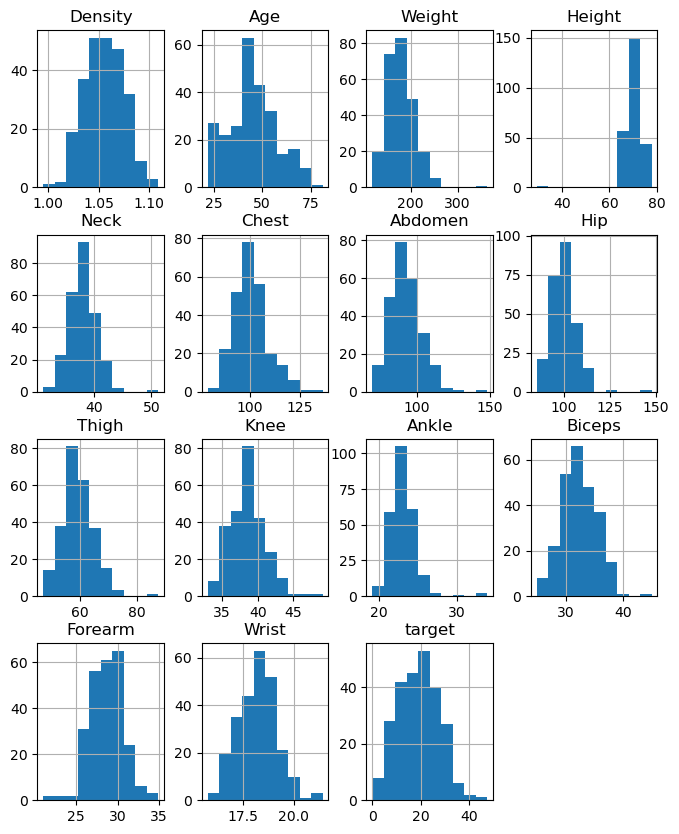

Scatter Matrix of All Features


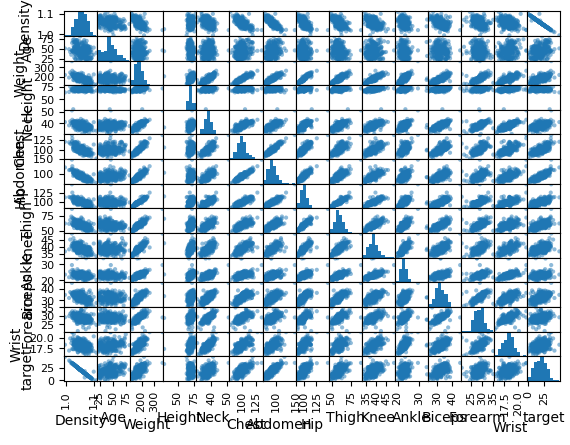

Box Plots of All Features


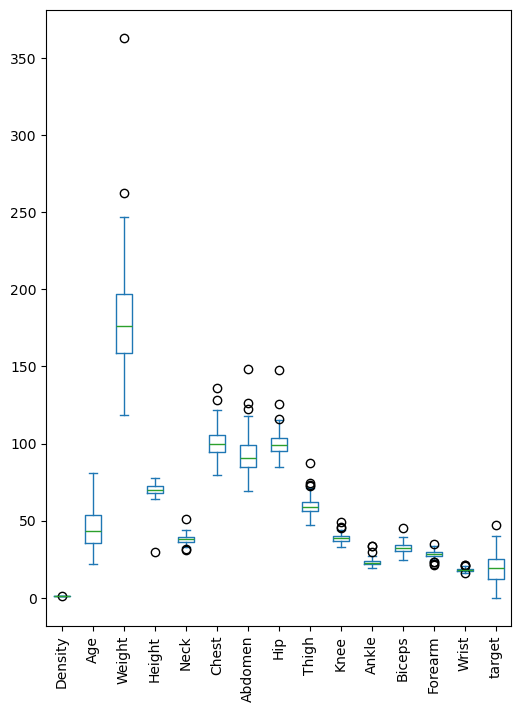

In [6]:
#EDA Graphs
print('Histograms of All Features')
_ = bodyfatset.hist(figsize=(8,10)) #histograms of all features
plt.show()

print('Scatter Matrix of All Features')
_ = pd.plotting.scatter_matrix(bodyfatset) #full scatter matrix all features
plt.show()

print('Box Plots of All Features')
_ = bodyfatset.plot(figsize = (6,8), kind='box') #box plot for all features
plt.xticks(rotation=90)
plt.show()

### Charts of Interest 

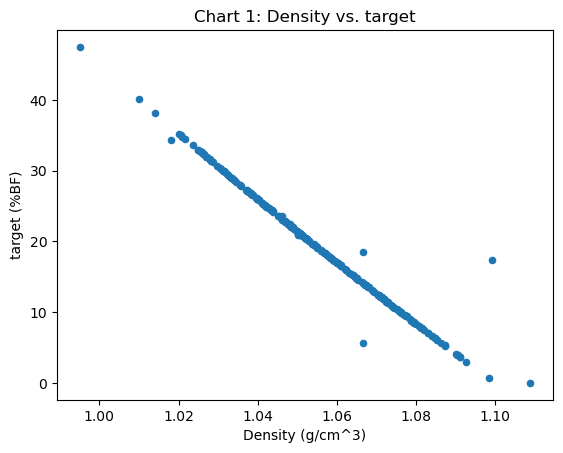

In [7]:
#Chart 1 - Density vs Target Scatter Plot 
bodyfatset.plot.scatter('Density', 'target')
plt.title('Chart 1: Density vs. target')
plt.xlabel('Density (g/cm^3)');
plt.ylabel('target (%BF)');

The density vs. target scatter plot was noteworthy due to the linear, highly negatively correlated shape of the graph. In the scatter matrix, this plot was the only pair of features with such a well-defined shape compared to all the other feature combinations that displayed a more cloud-like visualization. Conceptually, this was the result of body density being fundamental to calculating body fat percentage, and indeed during underwater (hydrostatic) weighing, formulas to compute an individual's body fat use density in their equations.

,target
count,252.000000
mean,19.150794
std,8.368740
min,0.000000
25%,12.475000
50%,19.200001
75%,25.299999
max,47.500000


,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,target
181,1.1089,40.0,118.5,68.0,33.799999,79.300003,69.400002,85.0,47.200001,33.5,20.200001,27.700001,24.6,16.5,0.0


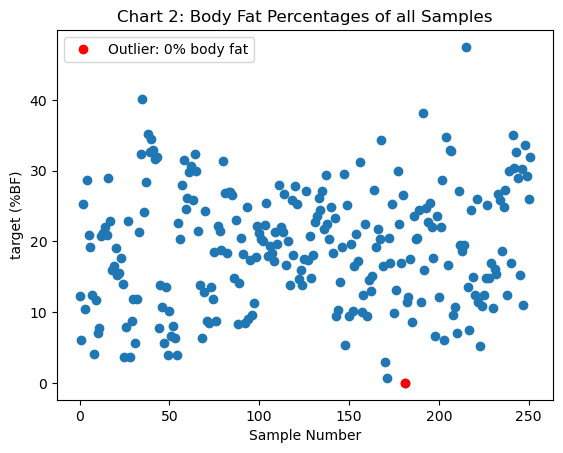

In [8]:
#Chart 2 - Body Fat Percentage Anomaly 
display(bodyfatset[['target']].describe()) #notice min here is 0.0
display(bodyfatset[bodyfatset['target']==0]) #finds specific row/sample where 0.0 BF 
plt.plot(bodyfatset['target'], 'o') #plots all samples/rows in dataset
plt.title('Chart 2: Body Fat Percentages of all Samples')
plt.xlabel('Sample Number')
plt.ylabel('target (%BF)')

#display outlier
outlier_index = bodyfatset[bodyfatset['target']==0].index[0] #.index returns array list of matching indexes
plt.plot(outlier_index, bodyfatset.loc[outlier_index,'target'], 'ro', label = 'Outlier: 0% body fat') #loc finds VALUE OF row number + column name so output 0.0 !
plt.legend();


After performing .describe() on the 'target' column in the dataset, a minimum value of 0.0 was shown which warranted further analysis because physiologically an individual cannot have zero body fat. So, a search for the specific sample row was performed to find the row number. Using this, a scatter plot of every sample's body fat percentage was plotted with the 0% body fat outlier highlighted as a red dot. This can be explained because body fat percentages were computed directly from bone density measurements, and an individual can be mathematically estimated to have zero body fat even though realistically they cannot.

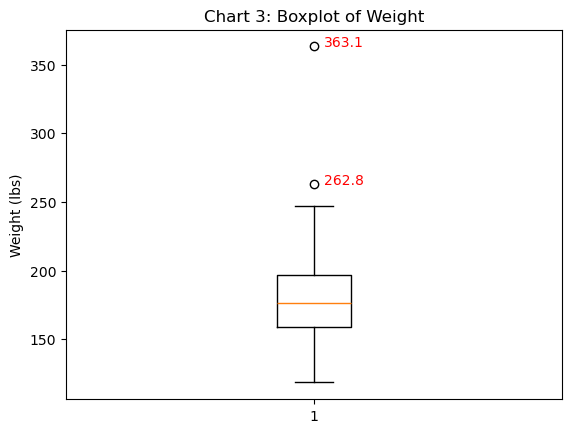

In [9]:
#Chart 3 - Boxplot of Weight with Outlier

plt.boxplot(bodyfatset['Weight'])

# Find outliers 
Q1 = bodyfatset['Weight'].quantile(0.25)
Q3 = bodyfatset['Weight'].quantile(0.75)
IQR =(Q3-Q1)
inner_upfence = Q3+1.5*IQR #254.0 lbs
outer_upfence = Q3 + 3*IQR #311.0 lbs
outliers = bodyfatset['Weight'][bodyfatset['Weight'] > inner_upfence]

# Annotate each outlier
for outlier in outliers: #insert text to describe outlier ! 
    plt.text(1.02, outlier, f"{outlier:.1f}", color='red') #x, y-axis, text, color

plt.title("Chart 3: Boxplot of Weight")
plt.ylabel("Weight (lbs)")
plt.show()


After exploring box plots for all features in the dataset, the boxplot of weight was particularly interesting due to the very large outlier well above the upper fence and the other values. As seen, two outliers highlighed in red were above the upper fence, but the topmost outlier was noteworthy with more than 100 pounds compared to the lower outlier. In fact, even when adjusting to compare the outer upper fence (311.0 lbs, Q3 + 3*IQR), this topmost outlier was still above that range. Conceptually, this could be considered when analyzing data such as the mean for the weight column, which could be skewed due to this extreme outlier.

### Correlation Analysis
Correlation analysis was performed to quantify linear relationships between numeric features and to identify potential multicollinearity. Understanding these relationships helps inform feature selection and interpretation of regression coefficients.

<Figure size 1800x1000 with 0 Axes>

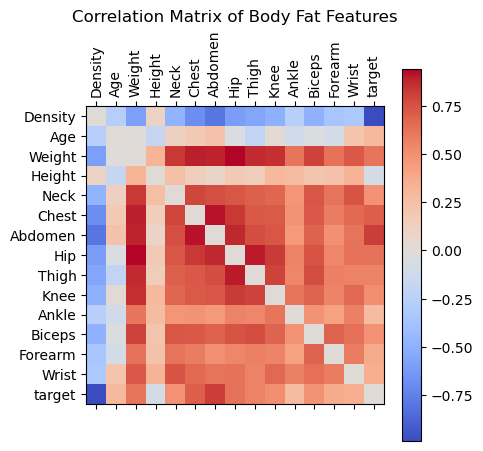

Most correlated pair of input columns: ('Weight', 'Hip') with value 0.9408841225678031


In [10]:
#Build correlation matrix and zero diagonals
corr = bodyfatset.corr() #2D DataFrame with all values for every combination features 
np.fill_diagonal(corr.values, 0) #remove self-correlation to highlight feature relationships

#Plot correlation matrix 
plt.figure(figsize=(18,10))
_ = plt.matshow(corr, cmap = 'coolwarm')

#Format plot
plt.colorbar()  #show numerical scale
plt.xticks(range(len(bodyfatset.columns)),bodyfatset.columns, rotation=90) #label x-axis with words vertical
plt.yticks(range(len(bodyfatset.columns)),bodyfatset.columns) #label y-axis 
plt.title('Correlation Matrix of Body Fat Features')
plt.show()

#Calculate most correlated 
featurescorr = featuresonly.corr() #need NEW corr matrix without target variable 
np.fill_diagonal(featurescorr.values, 0) #change diagonal again
corrstack = featurescorr.abs().stack() #stack makes long list of 14x14 corr combinations, abs value
pair = corrstack.idxmax() #.idmax identifies NAME LABEL
value = corrstack.max() #.max identifies numerical value 
print(f"Most correlated pair of input columns: {pair} with value {value}")


Based on the heatmap above, strong positive correlations (e.g. weight and hip) were represented with darker shades of red and strong negative correlations (e.g. density and target) were represented with darker shades of blue. The column pair most correlated (not including target variable) was 'Weight' vs. 'Hip' with a calculated value of 0.94; this reflects multicollinearity in anthropometric data, as weight and hip circumference are both affected by central fat distribution.

## Modeling

Three regression models were evaluated to compare predictive performance, model complexity, and generalization behavior.

1. Linear Regression Model - selected as baseline due to interpretability and likelihood of linear patterns between body measurements and body fat percentage.
2. Histogram-Based Gradient Boosting Model - higher-capacity ensemble model to evaluate more complex interactions in the data.
3. Decision Tree Regressor Model - included to capture potential non-linear patterns.

In [11]:
#1 Linear Regression Model
linear_model = sklearn.linear_model.LinearRegression()

#2 Histogram Gradient Boosted Trees
from sklearn import ensemble
histtree_model = sklearn.ensemble.HistGradientBoostingRegressor()

#3 Decision Tree Regressor
from sklearn import tree
decisiontree_model = sklearn.tree.DecisionTreeRegressor()


### Model Outputs with Loss Function


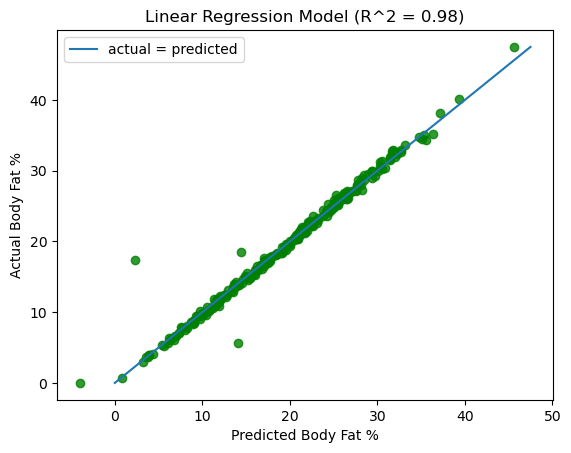

L1 Loss: 0.4802, L2 Loss: 1.5272


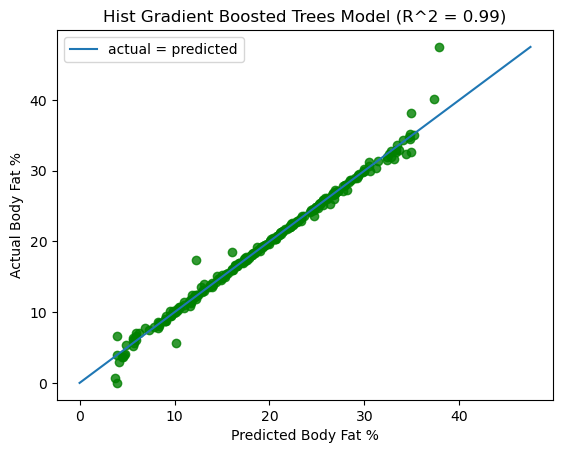

L1 Loss: 0.3779, L2 Loss: 0.9267


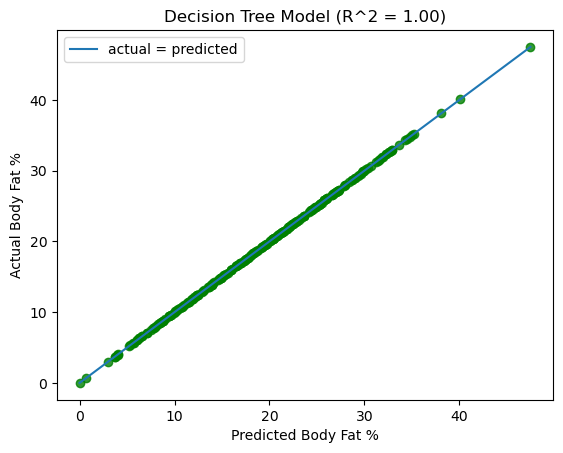

L1 Loss: 0.0000, L2 Loss: 0.0000


In [12]:
targetonly = bodyfatset[['target']] #only column of the target

#make function that auto plots each model with predictions
def plot_model(name, model):    #takes two inputs
    model_predictions = model.predict(featuresonly) 
    model_score = model.score(featuresonly, targetonly) #outputs model score R^2 value

    plt.plot( [0,targetonly.max().values[0]], [0,targetonly.max().values[0]], label = 'actual = predicted') #need max.values here y=x line
    plt.scatter(model_predictions, targetonly.values, color='green', alpha=0.8) #need .values for 1D array here
    plt.legend()
    plt.xlabel('Predicted Body Fat %')
    plt.ylabel('Actual Body Fat %')
    plt.title( f"{name} (R^2 = {model_score:.2f})")
    plt.show()
#REMEMBER -> underpredict = above y=x line, overpredict = under the line !

#make function to compute L2 and L1 losses
def lossfunc(model): 
    y_pred = model.predict(featuresonly) #shape (n,)
    y_actual = targetonly.values.ravel() #use ravel for 1D shape (n,)

    L1 = np.mean(np.abs(y_pred - y_actual)) 
    L2 = np.mean((y_pred - y_actual)**2) #MSE 
    print(f"L1 Loss: {L1:.4f}, L2 Loss: {L2:.4f}")

#1 Linear Model
linear_model.fit(featuresonly, targetonly['target']) #stricter need target 1D array (n,) 
plot_model("Linear Regression Model", linear_model)
lossfunc(linear_model)

#2 Histogram Gradient Boosted Trees
histtree_model.fit(featuresonly, targetonly['target']) #stricter need 1D array (n,) 
plot_model("Hist Gradient Boosted Trees Model", histtree_model)
lossfunc(histtree_model)

#3 Decision Trees 
decisiontree_model.fit(featuresonly, targetonly['target'])
plot_model("Decision Tree Model", decisiontree_model)
lossfunc(decisiontree_model)


3 different regression models were build above: linear regression, histogram gradient boosting tree, and decision tree. Each model was plotting comparing its predicted target values for % body fat compared to the actual target values in the dataset. The linear regression had the most L1 and L2 loss, whereas the decision tree model fit the data perfectly with zero L1 or L2 loss, indicative of overfitting.

Note: Because the linear regression model is the weighted sum of features (positive or negative values), a data point predicting negative body fat can actually be seen in the graph. 

### Model Evaluation

Model performance was evaluated using 5-fold cross-validation to assess generalization on unseen data. Mean squared error (L2 loss) was used as the evaluation metric to penalize larger prediction errors and provide a consistent comparison across models.

In [13]:
from sklearn.model_selection import cross_validate 

#make function that calculates cross-validated loss 
def cvloss(name, model):
    modelcv = cross_validate(model, featuresonly, targetonly.values.ravel(), cv=5, scoring = 'neg_mean_squared_error')
    cv_L2 = -1 * modelcv['test_score'].mean() #scikitlearn says higher=better, so that's why MSE is negative ! and multiply -1 
    print (f"{name} with cross-validation L2 loss: {cv_L2:.4f}")

#make function for L2 loss trained on whole dataset
def lossfunc(name, model):
    y_pred = model.predict(featuresonly)
    y_actual = targetonly.values.ravel()

    L2 = np.mean((y_pred - y_actual)**2) #MSE
    print (f"{name} original L2 loss: {L2:.4f}")

#1 Linear Model Cross-Validate
cvloss('Linear Regression Model', linear_model)
lossfunc('Linear Regression Model', linear_model)
print()

#2 Histogram Gradient Boosted Trees Cross-Validate
cvloss('Histogram Gradient Boosted Trees Model', histtree_model)
lossfunc('Histogram Gradient Boosted Trees Model', histtree_model)
print()

#3 Decision Tree Cross-Validate
cvloss('Decision Tree Model', decisiontree_model)
lossfunc('Decision Tree Model', decisiontree_model)

Linear Regression Model with cross-validation L2 loss: 1.9632
Linear Regression Model original L2 loss: 1.5272

Histogram Gradient Boosted Trees Model with cross-validation L2 loss: 3.0779
Histogram Gradient Boosted Trees Model original L2 loss: 0.9267

Decision Tree Model with cross-validation L2 loss: 4.7541
Decision Tree Model original L2 loss: 0.0000


After 5-fold cross-validation, models were compared using L2 loss averaged across folds. As expected, cross-validated loss was higher than training loss due to evaluation on held-out folds. The decision tree achieved zero training loss but showed the largest increase in cross-validated loss, indicating overfitting. Linear regression displayed the best generalization in having the most stable cross-validated performance and the lowest average loss.

### Model Standardization and Comparison
For further evaluation, standardization of features was performed and a comparison of training and cross-validated L2 loss was conducted to assess performance.

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline 
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error

targetonly = bodyfatset[['target']] #only column of the target

X = featuresonly
y_actual = targetonly.values.ravel()

cv = KFold(n_splits=5, shuffle=True, random_state=42)

#Function for standardized model original training L2 loss
def train_L2(name, pipeline):
    pipeline.fit(X,y_actual)
    y_pred = pipeline.predict(X)
    L2 = mean_squared_error(y_actual,y_pred) #MSE
    print (f"Standardized {name} with original training L2 loss: {L2:.4f}")

#Function for standardized model cross-validated L2 loss
def cv_L2(name, pipeline):
    cv_L2_scores = -1 * cross_val_score(pipeline, X, y_actual, cv=cv, scoring='neg_mean_squared_error') #negative MSE, so multiply -1 
    print (f"Standardized {name} with cross-validation L2 loss: {cv_L2_scores.mean():.4f}") #need avg of 5 scores so use mea


#1 Linear Model Pipeline
linear_pipeline= make_pipeline(StandardScaler(), sklearn.linear_model.LinearRegression())
train_L2('Linear Regression Model', linear_pipeline)
cv_L2('Linear Regression Model', linear_pipeline)
print()

#2 Histogram Gradient Boosted Trees Pipeline
from sklearn import ensemble
histtree_pipeline = make_pipeline(StandardScaler(), sklearn.ensemble.HistGradientBoostingRegressor())
train_L2('Histogram Gradient Boosted Trees Model', histtree_pipeline)
cv_L2('Histogram Gradient Boosted Tree Model', histtree_pipeline)
print()

#3 Decision Trees Pipeline
from sklearn import tree
decisiontree_pipeline = make_pipeline(StandardScaler(), sklearn.tree.DecisionTreeRegressor())
train_L2('Decision Tree Model', decisiontree_pipeline)
cv_L2('Decision Tree Model', decisiontree_pipeline)

Standardized Linear Regression Model with original training L2 loss: 1.5272
Standardized Linear Regression Model with cross-validation L2 loss: 2.0031

Standardized Histogram Gradient Boosted Trees Model with original training L2 loss: 0.9267
Standardized Histogram Gradient Boosted Tree Model with cross-validation L2 loss: 2.9477

Standardized Decision Tree Model with original training L2 loss: 0.0000
Standardized Decision Tree Model with cross-validation L2 loss: 3.1104


In [15]:
results_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Histogram Gradient Boosted Trees",
        "Decision Tree"
    ],
    "Training L2 Loss (MSE)": [
        1.5272,
        0.9267,
        0.0000
    ],
    "Cross-Validated L2 Loss (MSE)": [
        2.0031,
        2.9477,
        2.4758
    ]
})
#add change column
results_df["L2 Loss Change (CV - Train)"] = (
    results_df["Cross-Validated L2 Loss (MSE)"]
    - results_df["Training L2 Loss (MSE)"]
)

results_df

results_df

,Model,Training L2 Loss (MSE),Cross-Validated L2 Loss (MSE),L2 Loss Change (CV - Train)
0,Linear Regression,1.5272,2.0031,0.4759
1,Histogram Gradient Boosted Trees,0.9267,2.9477,2.0210
2,Decision Tree,0.0000,2.4758,2.4758


### Model Interpretation

After 5-fold cross-validation, models were compared using L2 loss (mean squared error) averaged across folds. As expected, cross-validated loss was higher than training loss due to evaluation on held-out folds.

Linear regression exhibited the smallest increase in L2 loss (0.4759) between training and cross-validation, displaying the most stable generalization performance among the three models. It also had the lowest final L2 loss score (2.0031). The tree-based models achieved much lower training error, but the substantially higher cross-validated loss indicates overfitting to the training data. This reflects memorization of the training set rather than actual predictive ability.

Note: Standardization did not change the L2 loss values for the linear and tree models. This is likely because standardization is compensated for with these models; even though the features were numerically scaled, the model's calculations also scale to adjust such as with coefficients or certain ordering. In contrast, other types of models that are sensitive to changing magnitudes such as K-means clustering or neural networks would have produced different original and standardized L2 loss values. 

### Model Selection Decision


The model chosen to be the best was based on the criteria of being able to not only make predictions accurately based on fitting the training data, but also its generalization ability to make accurate predictions based on new, unseen data. This criteria was chosen because the prospect of using models is largely for predictive performance in real-world contexts, such as estimating housing prices or determining the weather. 

Based on standardization, cross-validated L2 loss and generalization stability, linear regression was selected as the final model.

Contextually, this dataset includes physical measurements (continuous values) of individuals and their associated body fat percentages determined by underwater weighing. The fact that the linear regression model had the least L2 loss is logical since many variables showed strong linear relationships such as weight and hip circumference; physiologically, an individual with higher body measurements is likely to have a higher body fat percentage. As a result, using a non-linear method of model evaluation like trees might not be necessarily better/more accurate at predictions.


## Project Conclusion 

In [16]:
#Calculate RMSE for interpretation (standardizes units)
print(f"RMSE of linear model with cross-validation: {math.sqrt(2.0031):.4f}")

RMSE of linear model with cross-validation: 1.4153


Based on cross-validated performance, field-based anthropometric measurements can estimate body fat percentage with an average error of approximately 1–2 percentage points relative to hydrostatic-derived values. For example, if true body fat is calculated at 15%, the model, and thus field measurements, should predict around ~13.6-16.4%. While this level of accuracy does not replace gold-standard laboratory methods, it demonstrates that low-cost, non-invasive measurements can capture much of the relevant physiological information.

### Limitations
This analysis is based on measurements collected exclusively from adult males, which can limit the generalizability of the results to other populations. Additionally, the target variable (body fat percentage) is derived from body density measurements obtained via hydrostatic weighing, which introduces a deterministic relationship between certain features and the outcome. 

### Future Work 

Future analyses could explore feature subsets that exclude body density to better reflect real-world field applications, evaluate model effectiveness on other external datasets, or extend the findings to more diverse populations.


### References section 

**Dataset Source:**  
PMLB (Penn Machine Learning Benchmarks) – Body Fat Dataset (ID 560).  
EpistasisLab. Available at: https://github.com/EpistasisLab/pmlb/tree/master/datasets/560_bodyfat

Joseph D. Romano, Le, Trang T., William La Cava, John T. Gregg, Daniel J. Goldberg, Praneel Chakraborty, Natasha L. Ray, Daniel Himmelstein, Weixuan Fu, and Jason H. Moore. PMLB v1.0: an open source dataset collection for benchmarking machine learning methods. arXiv preprint arXiv:2012.00058 (2020).

